# **How are in-demand skills trending for Data Scientists?**

##### **Methodology**
1. Aggregate skill counts monthly
 2. Re-analyze based on percentage of total job posting
 3. Plot the monthly skill demand 

## *Imporitng libraries & Loading data* 

In [1]:
import pandas as pd
import ast 
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
# load dataset using load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()


## *Cleaning dataframe*

In [2]:
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

df['job_skills']=df['job_skills'].apply(lambda job: ast.literal_eval(job) if pd.notna(job) else job)

## *Aggregating skill counts monthly*


In [3]:
df_DS_US= df[(df['job_title_short']== 'Data Scientist') & (df['job_country']== 'United States')].copy()
df_DS_US.info()

<class 'pandas.DataFrame'>
Index: 58830 entries, 9 to 785692
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        58830 non-null  str           
 1   job_title              58830 non-null  str           
 2   job_location           58651 non-null  str           
 3   job_via                58830 non-null  str           
 4   job_schedule_type      58577 non-null  str           
 5   job_work_from_home     58830 non-null  bool          
 6   search_location        58830 non-null  str           
 7   job_posted_date        58830 non-null  datetime64[us]
 8   job_no_degree_mention  58830 non-null  bool          
 9   job_health_insurance   58830 non-null  bool          
 10  job_country            58830 non-null  str           
 11  salary_rate            6705 non-null   str           
 12  salary_year_avg        4553 non-null   float64       
 13  salary_hour_avg 

In [4]:
df_DS_US['month_no']= df_DS_US['job_posted_date'].dt.month
df_DS_US_exploded=df_DS_US.explode('job_skills')

In [5]:
df_skill_pivot= df_DS_US_exploded.pivot_table(index='month_no', columns='job_skills', aggfunc='size', fill_value=0)


df_skill_pivot.loc['total']= df_skill_pivot.sum()

df_skill_pivot=df_skill_pivot[df_skill_pivot.loc['total'].sort_values(ascending=False).index.to_list()]
df_skill_pivot.drop('total', inplace=True)

In [6]:
skills_pivot=df_skill_pivot.iloc[:, :5]

## *Re-analyzing based on percentage (%)*

In [7]:
# calculating the total of job posted months 
DS_totals = df_DS_US.groupby('month_no').size()

DS_totals


month_no
1     6915
2     4956
3     4779
4     4867
5     4377
6     4645
7     4876
8     6318
9     4568
10    4882
11    4175
12    3472
dtype: int64

In [8]:
# now finiding the percentages for each count of skills using div 
df_percent=df_skill_pivot.iloc[:12].div(DS_totals, axis=0)* 100
df_percent

job_skills,python,sql,r,sas,tableau,aws,spark,java,tensorflow,azure,...,asp.net core,clickup,couchdb,fedora,ocaml,mattermost,nuix,shogun,symfony,wrike
month_no,,,,,,,,,,,,,,,,,,,,,
1,75.820680,54.519161,48.618944,24.584237,23.571945,19.725235,19.609544,13.246565,12.957339,11.814895,...,0.014461,0.014461,0.014461,0.000000,0.000000,0.000000,0.014461,0.000000,0.014461,0.000000
2,75.020178,53.874092,47.094431,23.083132,25.585149,17.231638,18.058918,13.014528,11.400323,11.561743,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,71.019042,50.763758,45.804562,23.938062,23.561415,17.744298,16.467880,12.031806,11.069261,11.257585,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020925,0.000000,0.000000
4,74.419560,50.606123,44.811999,24.738032,24.922950,18.122046,16.909801,12.779947,11.958085,11.054037,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,73.840530,52.387480,46.058944,26.273703,26.822024,18.208819,17.683345,14.370573,11.811743,11.903130,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,73.864370,52.572659,45.360603,24.930032,24.434876,17.610334,17.696448,12.615716,11.560818,12.228202,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021529
7,72.621001,50.840853,45.324036,22.682527,25.082034,17.637408,16.447908,11.915505,11.689910,12.448728,...,0.000000,0.000000,0.000000,0.020509,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,72.269706,52.611586,45.837290,25.292814,24.058246,17.030706,17.014878,12.139918,12.804685,11.506806,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,68.126095,47.176007,39.207531,25.350263,20.161996,15.258319,16.199650,11.690018,12.412434,12.215412,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='month_no'>

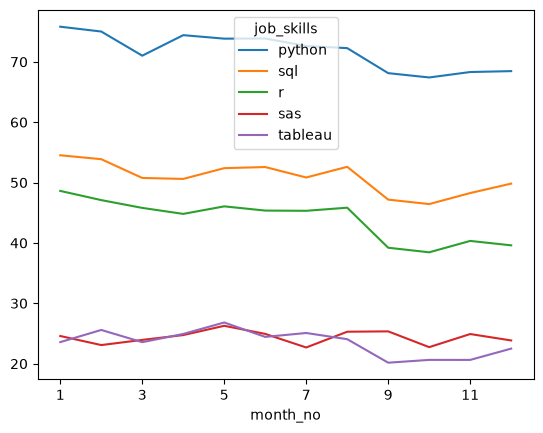

In [9]:
df_percent.iloc[:, :5].plot(kind='line')

In [10]:
#change the month number to month names 
df_percent= df_percent.reset_index()
df_percent['posted_month_name']= df_percent['month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_percent= df_percent.drop(columns='month_no')
df_percent=df_percent.set_index('posted_month_name')

## Plotting monthly skills demand

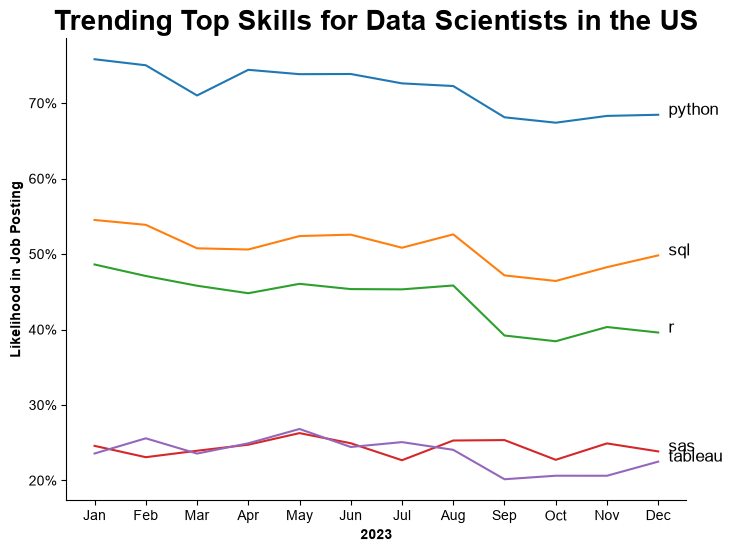

In [11]:
from matplotlib.ticker import PercentFormatter
df_plot=df_percent.iloc[:12, :5]

plt.figure(figsize=(8,6))
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.title('Trending Top Skills for Data Scientists in the US', weight='bold', fontsize=20)
plt.ylabel('Likelihood in Job Posting',weight='bold')
plt.xlabel('2023',weight='bold')
plt.legend().remove()


# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')
plt.show()
